In [1]:
import rasterio

fp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/1/dem_latlon.tif"
with rasterio.open(fp) as ds:
    print("CRS:", ds.crs)
    print("Width, Height:", ds.width, ds.height)
    print("Pixel size:", ds.res)
    print("Bounds:", ds.bounds)

CRS: EPSG:4326
Width, Height: 1801 1801
Pixel size: (0.0008333333333333, 0.0008333333333333)
Bounds: BoundingBox(left=-106.45041666666549, bottom=35.049583333332606, right=-104.94958333333221, top=36.55041666666588)


In [2]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
import rasterio
from pathlib import Path
import geospatialtools.gdal_tools as gdal_tools


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/


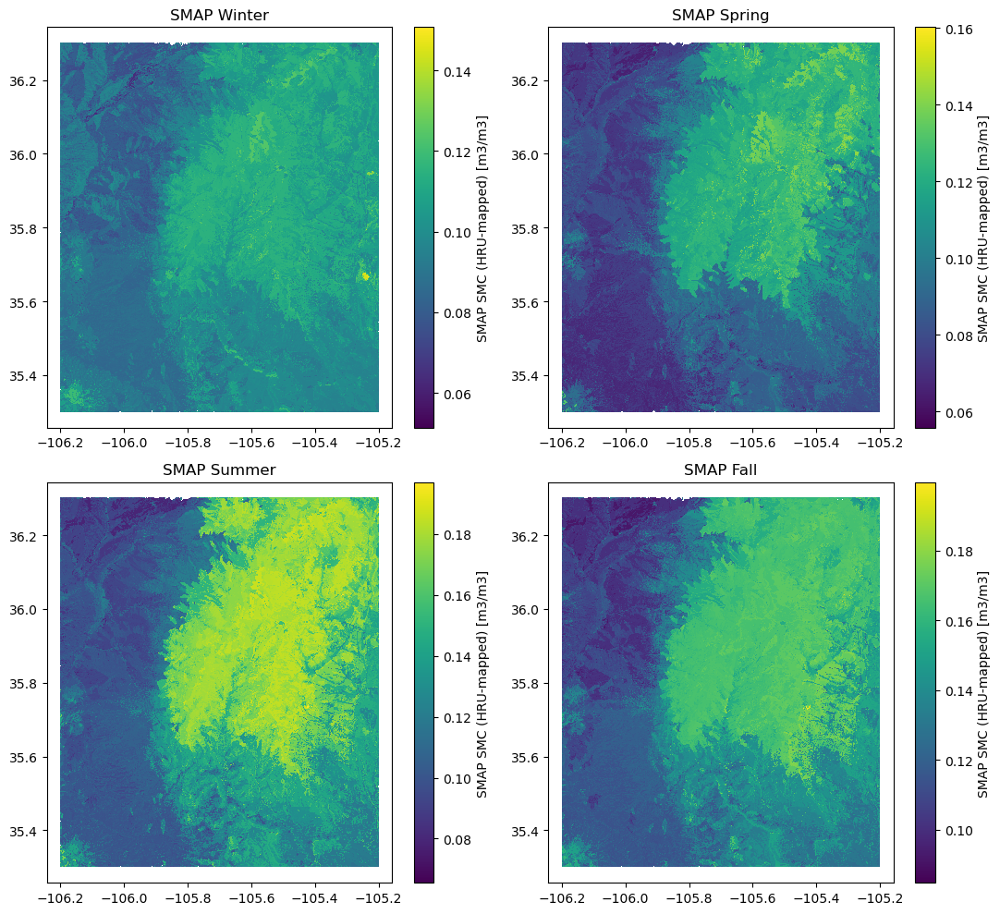

In [1]:
import numpy as np
import netCDF4 as nc
import numba
import pandas as pd
import geospatialtools.gdal_tools as gdal_tools
import gdal_tools
import sys
import matplotlib.pyplot as plt
import rasterio
import os, re, glob
import matplotlib.colors as colors
import rasterio
from pathlib import Path
import gdal_tools

#model outputs
path_pp = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/'
path_3d = '/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/'

#satelite dat
smap_sat = "/scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/"
#Ndmi_sat = '/scratch/alpine/battobrah@xsede.org/landsat_ndmi/NORTHERN_NM_MONTHLY_PER_YEAR_2014_2024/'

print(path_pp)
print(path_3d)


outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/"

# ------------------------------------
# READ TIME FROM INPUT FILE (REQUIRED)
# ------------------------------------
fp = nc.Dataset(path_3d + "1/input_file.nc")
time = fp.groups["meteorology"]["time"][:]   # hours since start
fp.close()

# ------------------------------------
# BUILD DATETIME VECTOR (PROF STYLE)
# ------------------------------------
start = pd.Timestamp("2014-01-01 00:00")

datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")


# Read HRU grid + metadata
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 250
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])
coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

with rasterio.open(path + "postprocess/cids.vrt") as ds:
    cids = ds.read(1)

# Force HRU count to match model outputs (1000)
with nc.Dataset(path + "output_data/1/2016-01-01.nc") as ds:
    nhrus = ds.groups["data"].variables["totsmc"].shape[1]

def read_grid(fp):
    with rasterio.open(fp) as ds:
        arr = ds.read(1).astype(np.float32)
        nod = ds.nodata
        if nod is not None:
            arr[arr == nod] = np.nan
        arr[arr == -9999.0] = np.nan
        return arr

''' Aggregate a gridded field (SMAP soil moisture) to HydroBlocks HRUs
    using an area-weighted mean.

    Math:
        For each HRU h,
            SM_h = (Σ SMAP_p) / N_h

        where SMAP_p are grid-cell values inside HRU h and N_h is the number
        of equal-area grid cells belonging to that HRU.

    Notes:
    - All HydroBlocks grid cells have equal area, so a simple mean is
      equivalent to an area-weighted average.
    - HRU membership is defined by the hrus raster; cids is used to
      restrict aggregation to a specific cluster/domain. 
'''
      
def grid_to_hru_mean(grid, hrus, cids, val, nhrus):
    m = (hrus > 0) & (cids == val) & np.isfinite(grid)    # selecting valid HRU, i.e hru > 0
    idx  = hrus[m].astype(np.int64) - 1             # give the HRU ID for each selected cell, -1 converts HRU IDs from 1..n to 0..n-1 (Python indexing), it tells the k-th selected cell belongs to HRU h = idx(k)
    vals = grid[m].astype(np.float64)               # extracts the fine-grid SMAP values for those same cells
    sums = np.bincount(idx, weights=vals, minlength=nhrus)      # np.bincount groups by HRU index
    cnts = np.bincount(idx, minlength=nhrus)            # This counts how many selected cells fell into each HRU
    out = np.full(nhrus, np.nan)
    ok = cnts > 0
    out[ok] = sums[ok] / cnts[ok]
    return out

def place_data(tmp, model, hrus, cids, val):
    out = np.copy(tmp)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            hru  = int(hrus[i, j])
            ucid = int(cids[i, j])
            if (hru > 0) and (ucid == val):
                out[i, j] = model[hru - 1]
    return out

# SMAP monthly files
pat = re.compile(r".*SMAP_B1_(\d{6})_MODELGRID_4326_monthlymean\.tif$")
rows = []
for fp in sorted(glob.glob(os.path.join(smap_sat, "*.tif"))):
    m = pat.match(os.path.basename(fp))
    if not m:
        continue
    dt = pd.to_datetime(m.group(1), format="%Y%m")
    if 2016 <= dt.year <= 2018:
        rows.append((dt, fp))

if not rows:
    raise RuntimeError(f"No SMAP monthly files matched for 2016–2018 in: {smap_sat}")

rows.sort(key=lambda x: x[0])       # sorting by first element

# Seasonal plotting
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

# for dataframe table
season_mean_table = {}

for iss, my_season in enumerate(seasons):
    months = season_months[iss]
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months] #Looping over smap files by months

    if not season_arrays:
        axes[iss].axis("off")
        continue

    season_mean_grid = np.nanmean(np.stack(season_arrays, axis=0), axis=0)
    smap_hru = grid_to_hru_mean(season_mean_grid, hrus, cids, val=1, nhrus=nhrus) #aggregate SMAP grid soil moisture to HRU space
    season_mean_table[my_season] = smap_hru    #store the seasonal SMAP HRU-mean soil moisture in a dictionary for later analysis

    tmp = np.full_like(hrus, -9999.0, dtype=np.float32)
    final_map = place_data(tmp, smap_hru, hrus, cids, val=1)
    final_map[final_map == -9999.0] = np.nan

    final_map = final_map[buffer:final_map.shape[0]-buffer+1, buffer:final_map.shape[1]-buffer+1]

    ax = axes[iss] # plotting in seasonal order
    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map), cmap="viridis", shading="auto")
    #ax.set_title("SMAP" + my_season)
    ax.set_title(f"SMAP {my_season}")
    fig.colorbar(im, ax=ax, label="SMAP SMC (HRU-mapped) [m3/m3]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "smap_seasonal_hru_mapped_2016_2018.png"), dpi=300)
plt.show()

In [3]:
df = pd.DataFrame.from_dict(season_mean_table, orient="index")

df["SMAP_mean (m3m3)"] = df.mean(axis=1, skipna=True)
df["SMAP_min (m3m3)"]  = df.min(axis=1, skipna=True)
df["SMAP_max (m3m3)"]  = df.max(axis=1, skipna=True)

'''
df["SMAP_mean (m3m3)"] = df.apply(lambda r: np.nanmean(r.values), axis=1)
df["SMAP_min (m3m3)"]  = df.apply(lambda r: np.nanmin(r.values),  axis=1)
df["SMAP_max (m3m3)"]  = df.apply(lambda r: np.nanmax(r.values),  axis=1)
'''

# keep only the summary columns
df = df[[
    "SMAP_mean (m3m3)",
    "SMAP_min (m3m3)",
    "SMAP_max (m3m3)"
]]

df


,SMAP_mean (m3m3),SMAP_min (m3m3),SMAP_max (m3m3)
Winter,0.097003,0.051392,0.150702
Spring,0.099081,0.055784,0.160234
Summer,0.131573,0.065505,0.196988
Fall,0.135042,0.084839,0.199495


In [4]:
annual_mean_table = {}

for year in [2016, 2017, 2018]:
    year_arrays = []

    for dt, fp in rows:
        if dt.year == year:
            year_arrays.append(read_grid(fp))

    year_mean = np.nanmean(np.stack(year_arrays, axis=0), axis=0)
    smap_hru = grid_to_hru_mean(year_mean, hrus, cids, 1, nhrus)

    annual_mean_table[year] = {
        "SMAP_domain_mean_m3m3": np.nanmean(smap_hru),
        "SMAP_min_m3m3": np.nanmin(smap_hru),
        "SMAP_max_m3m3": np.nanmax(smap_hru),
    }

pd.DataFrame.from_dict(annual_mean_table, orient="index")



,SMAP_domain_mean_m3m3,SMAP_min_m3m3,SMAP_max_m3m3
2016,0.119265,0.069289,0.170947
2017,0.121906,0.069322,0.174797
2018,0.106002,0.061966,0.151389


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


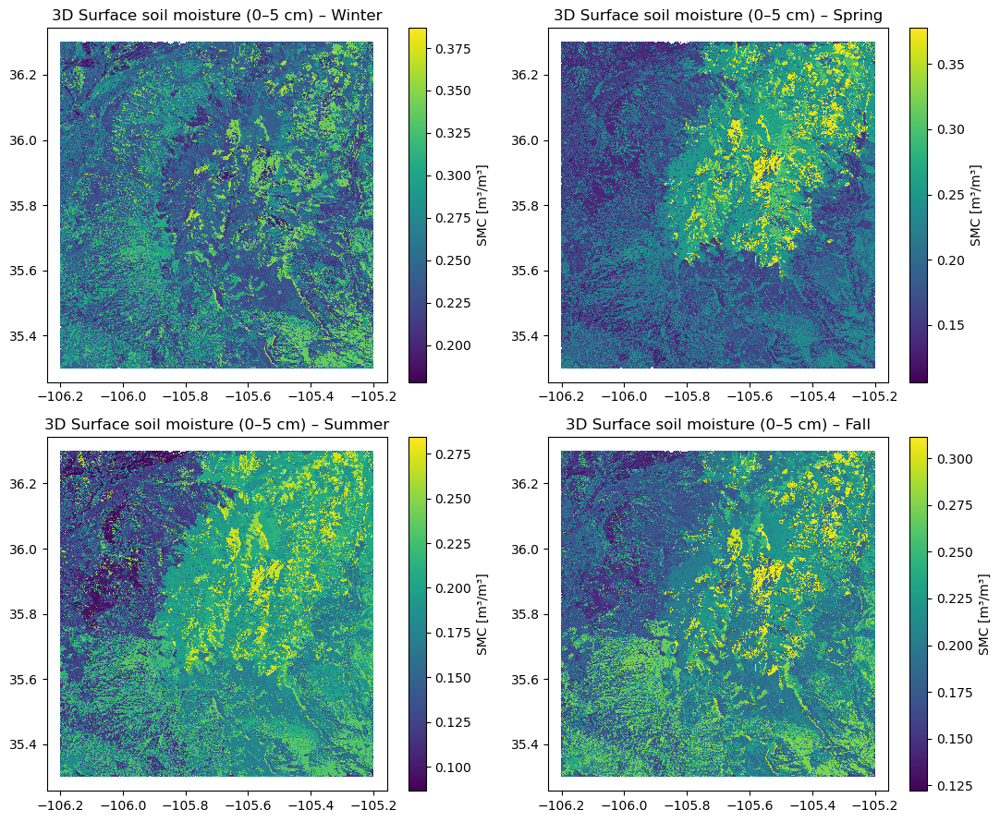

In [5]:
# soil moisture (smc) seasonal plots (TOP LAYER, 2 per row)

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]



tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout 
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        smc = np.array(grp.variables["smc"][:])     # (time, hru, soil)
        data = smc[:, :, 0]                          # TOP SOIL LAYER (0–5 cm)

        fp.close()

        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)      # (hru,)

        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis", shading="auto"
    )

    ax.set_title(f"3D Surface soil moisture (0–5 cm) – {my_season}")
    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_smc_surface_seasonal.png"),
    dpi=300
)
plt.show()


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


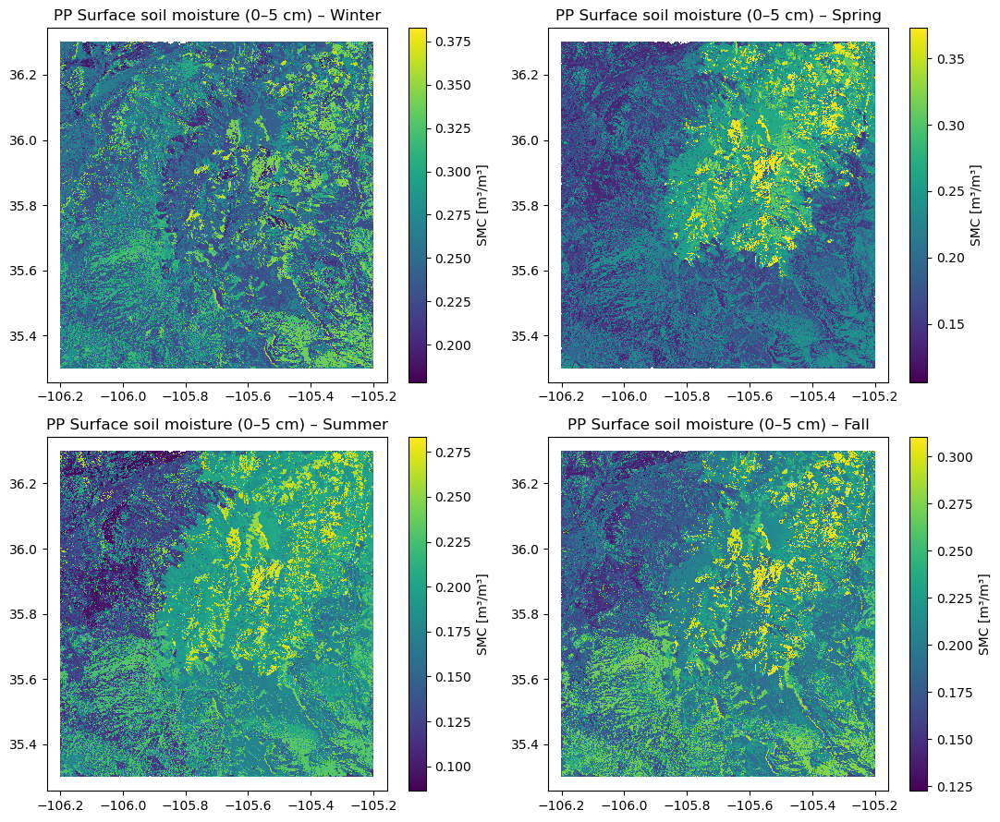

In [6]:
# soil moisture (smc) seasonal plots — (TOP LAYER, 2 per row) — PP

path = path_pp
print(path)

# HRU & CID rasters (use PP postprocess; should match 3D but keep consistent)
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# layout 
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        smc = np.array(grp.variables["smc"][:])      # (time, hru, soil)
        data = smc[:, :, 0]                          # TOP SOIL LAYER (0–5 cm)

        fp.close()

        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)      # (hru,)

        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="viridis", shading="auto"
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_smc_surface_seasonal_PP.png"),
    dpi=300
)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
SMAP: /scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


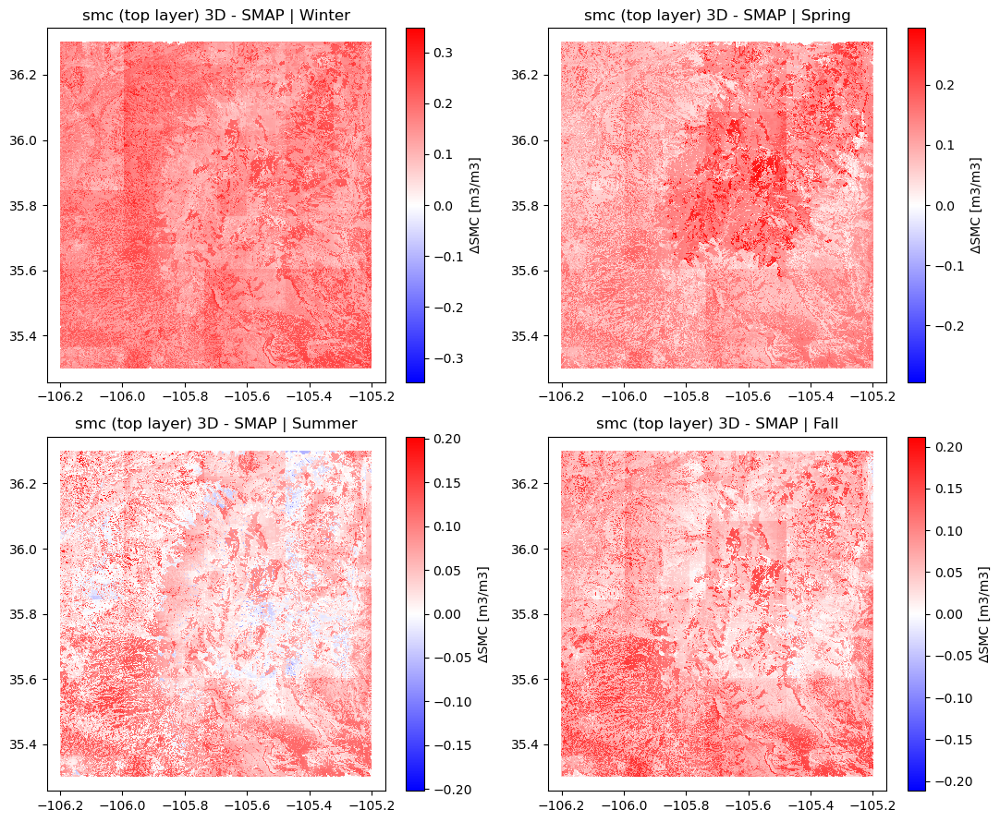

In [7]:
# 3D - SMAP seasonal difference maps (SMC top layer, 0–5 cm) 

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("SMAP:", smap_sat)

# hrus should be the same between the two datasets (we use model grid for mapping)
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons 
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# SMAP: monthly files -> seasonal mean grid
pat = re.compile(r".*SMAP_B1_(\d{6})_MODELGRID_4326_monthlymean\.tif$")

def build_smap_rows(smap_folder):
    files = sorted(glob.glob(os.path.join(smap_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.to_datetime(yyyymm, format="%Y%m")
        # match your run window
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows = sorted(rows, key=lambda x: x[0])
    if len(rows) == 0:
        raise RuntimeError("No SMAP monthly files matched for 2016–2018 in: {}".format(smap_folder))
    return rows

def smap_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # you already have read_grid() in your notebook
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

smap_rows = build_smap_rows(smap_sat)

# PLOT: 2x2 
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # 3D model seasonal mean (TOP LAYER) in HRU space 
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    smc_3d = np.array(grp_3d.variables["smc"][:])[:, :, 0]   # TOP SOIL LAYER (0–5 cm)
    fp_3d.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    smc_3d_sel = smc_3d[times_index, :]
    smc_3d_ave = np.nanmean(smc_3d_sel, axis=0)  # (hru,)

    # map model HRU -> grid 
    map_3d = place_data(tmp, smc_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d[map_3d == -9999] = np.nan

    #  SMAP seasonal mean on model grid ----
    smap_map = smap_season_mean(smap_rows, my_months)
    if smap_map is None:
        ax.axis("off")
        continue

    # remove buffer 
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    smap_map = smap_map[buffer:smap_map.shape[0]-buffer+1, buffer:smap_map.shape[1]-buffer+1]

    # difference: 3D - SMAP
    final_map = map_3d - smap_map

    # symmetric diverging norm (like his difference plots)
    vmax = np.nanmax(np.abs(final_map))
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("smc (top layer) 3D - SMAP | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSMC [m3/m3]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_smc_surface_3D_minus_SMAP_maps.png"), dpi=300)
plt.show()


SMAP vs 3D: Winter
SMAP vs 3D: Spring
SMAP vs 3D: Summer
SMAP vs 3D: Fall


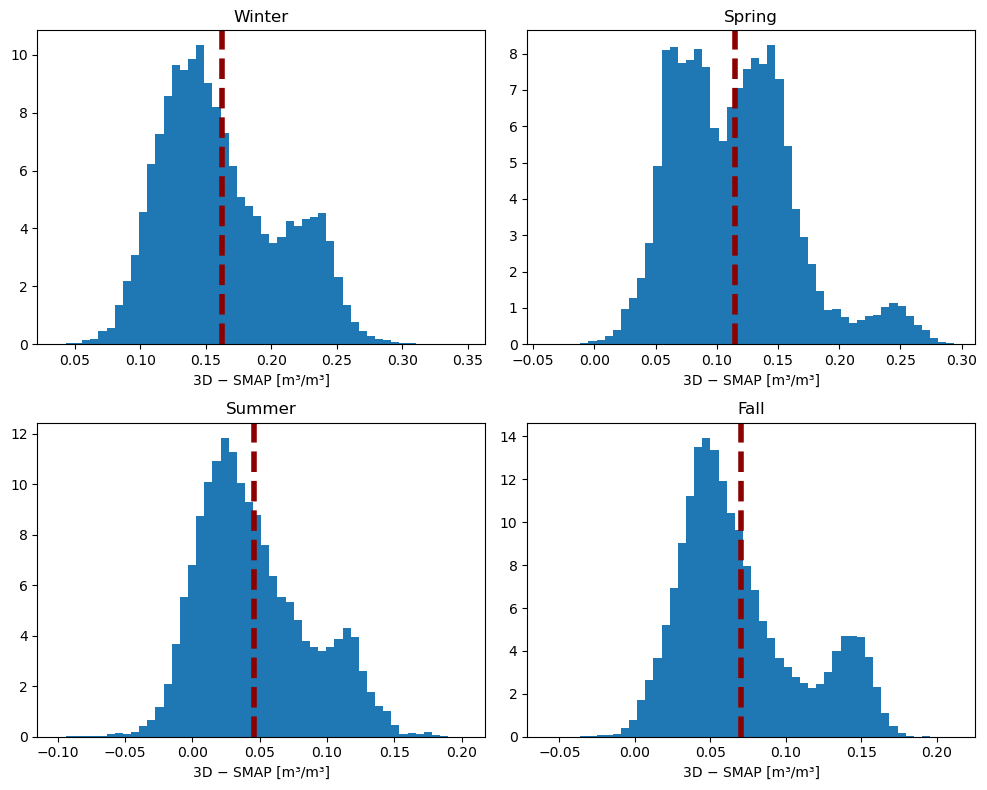

In [8]:
# 3D vs Smap difference Histogram Plot


path_domain = path_3d

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def smap_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No SMAP files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"SMAP vs 3D: {my_season}")

    # 3D seasonal mean (HRU space) 
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    smc_3d = np.array(fp_3d.groups["data"].variables["smc"][:])[:, :, 0]
    fp_3d.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    smc3d_mean = np.nanmean(smc_3d[idx, :], axis=0)

    #  SMAP seasonal mean (grid) 
    smap_grid = smap_season_mean_grid(smap_rows, my_months)
    smap_grid = smap_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map 3D HRU → grid 
    smc3d_grid = place_data(tmp, smc3d_mean, hrus, cids, 1)
    smc3d_grid = np.where(smc3d_grid == -9999, np.nan, smc3d_grid)
    smc3d_grid = smc3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    #  difference 
    diff = smc3d_grid - smap_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D − SMAP [m³/m³]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir,
            "res_hist_smc_surface_3D_minus_SMAP.png"), dpi=300)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
3D - PP maps: Winter
3D - PP maps: Spring
3D - PP maps: Summer
3D - PP maps: Fall


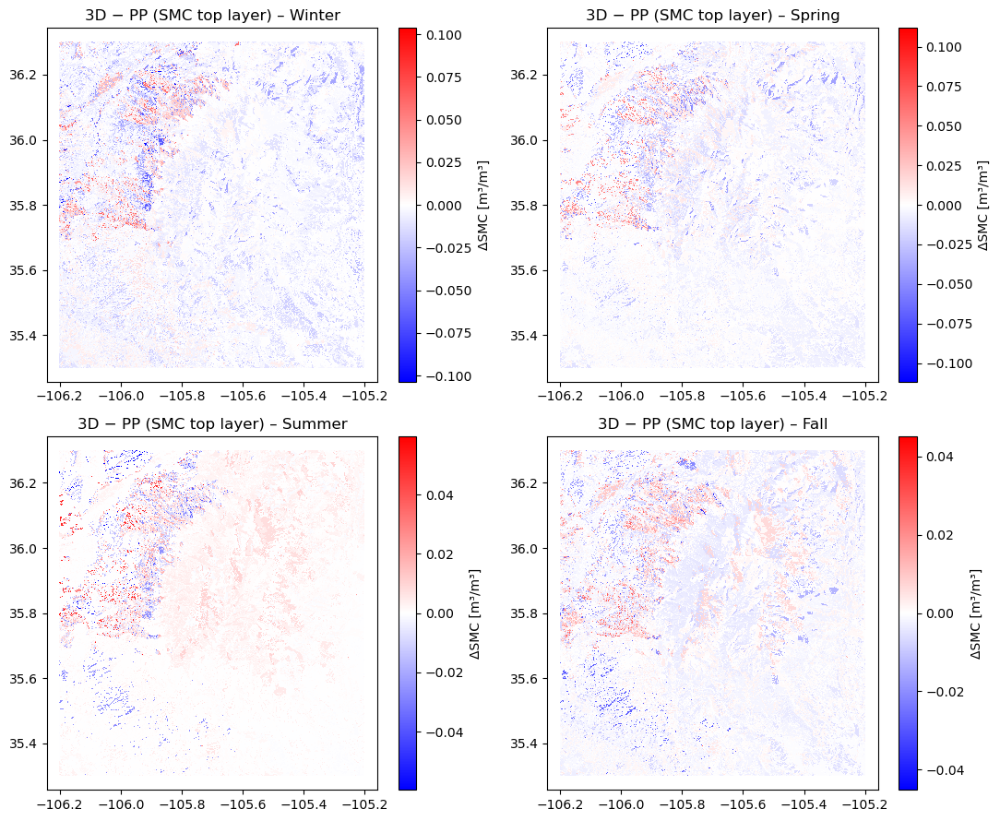

In [9]:
# 3D - PP seasonal difference maps (smc top layer, 0–5 cm) 

# Paths
path_3d = path_3d
path_pp = path_pp
print("3D:", path_3d)
print("PP:", path_pp)

# Use ONE postprocess domain (HRUs/CIDs should match). Pick 3D for consistency:
path_domain = path_3d

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"3D - PP maps: {my_season}")

    #  read 3D 
    ds3 = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    smc3 = np.array(ds3.groups["data"].variables["smc"][:])[:, :, 0]   # TOP LAYER
    ds3.close()

    #  read PP 
    dsp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    smcp = np.array(dsp.groups["data"].variables["smc"][:])[:, :, 0]   # TOP LAYER
    dsp.close()

    #  seasonal mean in HRU space 
    idx = times.dt.month.isin(my_months).to_numpy()
    smc3_mean = np.nanmean(smc3[idx, :], axis=0)   # (hru,)
    smcp_mean = np.nanmean(smcp[idx, :], axis=0)   # (hru,)

    diff_hru = smc3_mean - smcp_mean

    #  map to grid 
    final_map = place_data(tmp, diff_hru, hrus, cids, 1)
    final_map = np.where(final_map == -9999, np.nan, final_map)

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]
    vmax = np.nanmax(np.abs(final_map))
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="bwr", norm=diff_norm, shading="auto"
    )

    
    '''im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="bwr", shading="auto" 
    )
    '''
    ax.set_title(f"3D − PP (SMC top layer) – {my_season}")
    fig.colorbar(im, ax=ax, label="ΔSMC [m³/m³]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_smc_surface_3D_minus_PP_maps.png"), dpi=300)
plt.show()


3D - PP hist: Winter
3D - PP hist: Spring
3D - PP hist: Summer
3D - PP hist: Fall


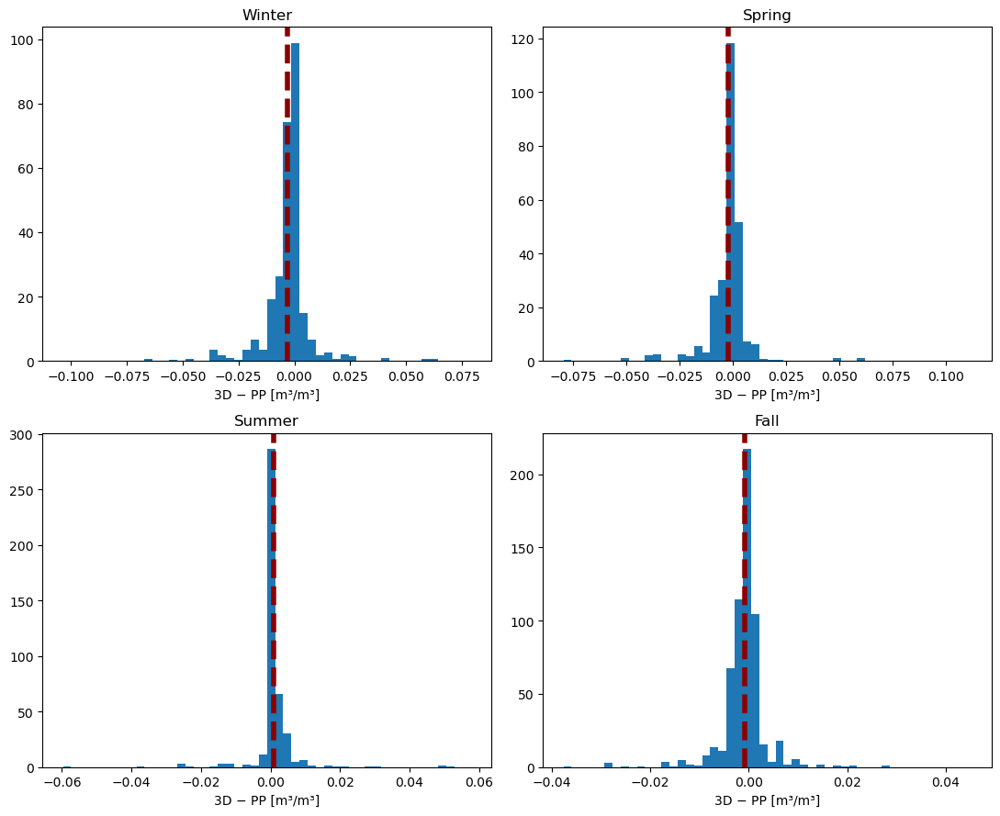

In [10]:
# 3D - PP seasonal difference histograms (smc top layer, 0–5 cm) 

path_domain = path_3d  # use 3D postprocess for mapping
hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print(f"3D - PP hist: {my_season}")

    ds3 = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    smc3 = np.array(ds3.groups["data"].variables["smc"][:])[:, :, 0]
    ds3.close()

    dsp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    smcp = np.array(dsp.groups["data"].variables["smc"][:])[:, :, 0]
    dsp.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    smc3_mean = np.nanmean(smc3[idx, :], axis=0)
    smcp_mean = np.nanmean(smcp[idx, :], axis=0)

    diff_hru = smc3_mean - smcp_mean
    diff_map = place_data(tmp, diff_hru, hrus, cids, 1)
    diff_map = np.where(diff_map == -9999, np.nan, diff_map)

    map_shape = diff_map.shape
    diff_map = diff_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    arr = diff_map.ravel()
    arr = arr[np.isfinite(arr)]

    #  HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle="dashed", linewidth=4, color="darkred")
    ax.set_title(my_season)
    ax.set_xlabel("3D − PP [m³/m³]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_hist_smc_surface_3D_minus_PP.png"), dpi=300)
plt.show()


PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
SMAP: /scratch/alpine/battobrah@xsede.org/smap_monthly_smc_4326/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


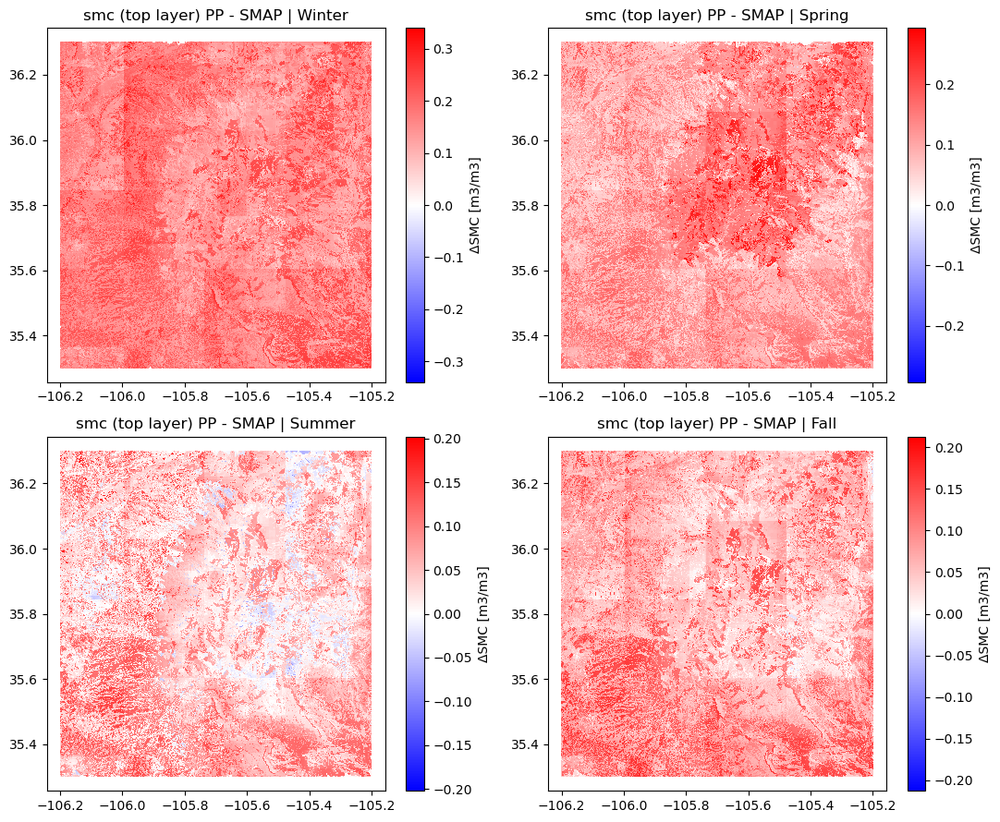

In [11]:
# PP - SMAP seasonal difference maps (SMC top layer, 0–5 cm) 

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("PP:", path_pp)
print("SMAP:", smap_sat)

# use PP domain for mapping (HRUs/CIDs should match 3D, but keep consistent with PP)
path = path_pp

# read mapping rasters 
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp = np.copy(hrus)
tmp[:] = -9999.0

# seasons 
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

#  SMAP: monthly files -> seasonal mean grid
pat = re.compile(r".*SMAP_B1_(\d{6})_MODELGRID_4326_monthlymean\.tif$")

def build_smap_rows(smap_folder):
    files = sorted(glob.glob(os.path.join(smap_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyymm = m.group(1)
        dt = pd.to_datetime(yyyymm, format="%Y%m")
        # match your run window
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows = sorted(rows, key=lambda x: x[0])
    if len(rows) == 0:
        raise RuntimeError("No SMAP monthly files matched for 2016–2018 in: {}".format(smap_folder))
    return rows

def smap_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # you already have read_grid() in your notebook
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

smap_rows = build_smap_rows(smap_sat)

#  PLOT: 2x2 
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    #  PP model seasonal mean (TOP LAYER) in HRU space 
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    smc_pp = np.array(grp_pp.variables["smc"][:])[:, :, 0]   # TOP SOIL LAYER (0–5 cm)
    fp_pp.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    smc_pp_sel = smc_pp[times_index, :]
    smc_pp_ave = np.nanmean(smc_pp_sel, axis=0)  # (hru,)

    # map model HRU -> grid 
    map_pp = place_data(tmp, smc_pp_ave, hrus, cids, 1)
    map_pp = np.ma.masked_array(map_pp, map_pp == -9999)
    map_pp[map_pp == -9999] = np.nan

    #  SMAP seasonal mean on model grid 
    smap_map = smap_season_mean(smap_rows, my_months)
    if smap_map is None:
        ax.axis("off")
        continue

    #  remove buffer 
    map_shape = map_pp.shape
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    smap_map = smap_map[buffer:smap_map.shape[0]-buffer+1, buffer:smap_map.shape[1]-buffer+1]

    #  difference: PP - SMAP 
    final_map = map_pp - smap_map

    # symmetric diverging norm (like his difference plots)
    '''
    mymin = np.abs(np.nanmin(final_map))
    mymax = np.abs(np.nanmax(final_map))
    diff_norm = colors.TwoSlopeNorm(
        vmin=-max(mymin, mymax),
        vcenter=0.0,
        vmax=max(mymin, mymax)
    )
    '''
    vmax = np.nanmax(np.abs(final_map))
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("smc (top layer) PP - SMAP | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSMC [m3/m3]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_smc_surface_PP_minus_SMAP_maps.png"), dpi=300)
plt.show()


SMAP vs PP: Winter
SMAP vs PP: Spring
SMAP vs PP: Summer
SMAP vs PP: Fall


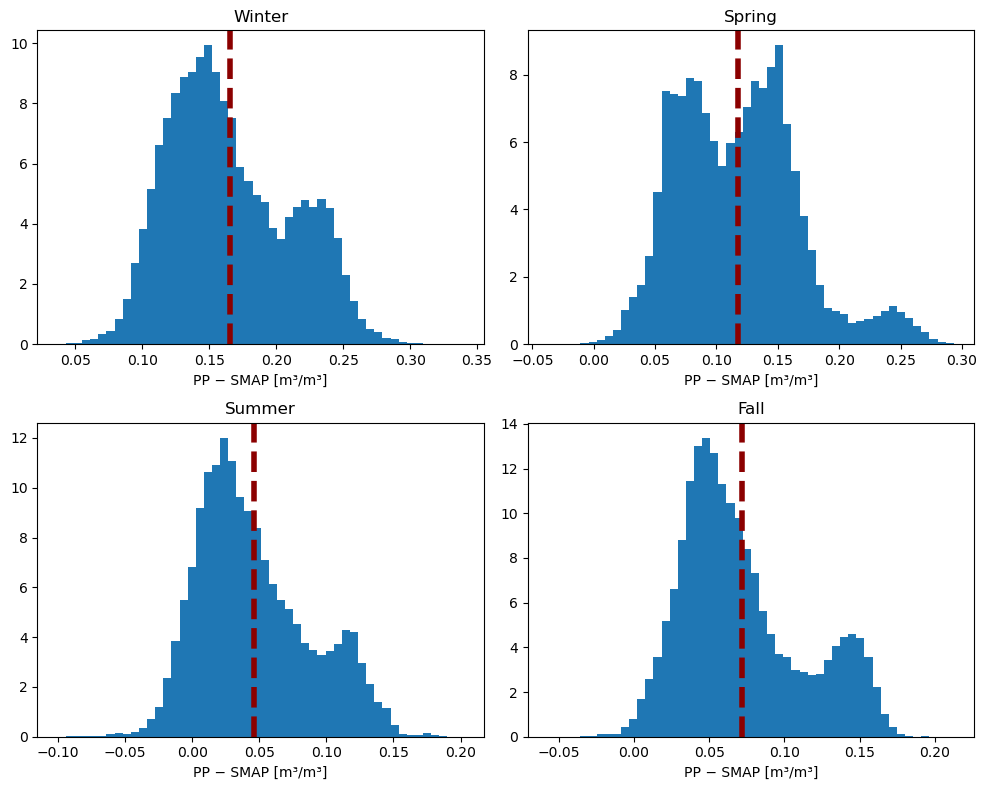

In [12]:
# PP vs Smap difference Histogram Plot

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"SMAP vs PP: {my_season}")

    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    smc_pp = np.array(fp_pp.groups["data"].variables["smc"][:])[:, :, 0]
    fp_pp.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    smcpp_mean = np.nanmean(smc_pp[idx, :], axis=0)

    smap_grid = smap_season_mean_grid(smap_rows, my_months)
    smap_grid = smap_grid[buffer:-buffer+1, buffer:-buffer+1]

    smcpp_grid = place_data(tmp, smcpp_mean, hrus, cids, 1)
    smcpp_grid = np.where(smcpp_grid == -9999, np.nan, smcpp_grid)
    smcpp_grid = smcpp_grid[buffer:-buffer+1, buffer:-buffer+1]

    diff = smcpp_grid - smap_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("PP − SMAP [m³/m³]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir,
            "res_hist_smc_surface_PP_minus_SMAP.png"), dpi=300)
plt.show()


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


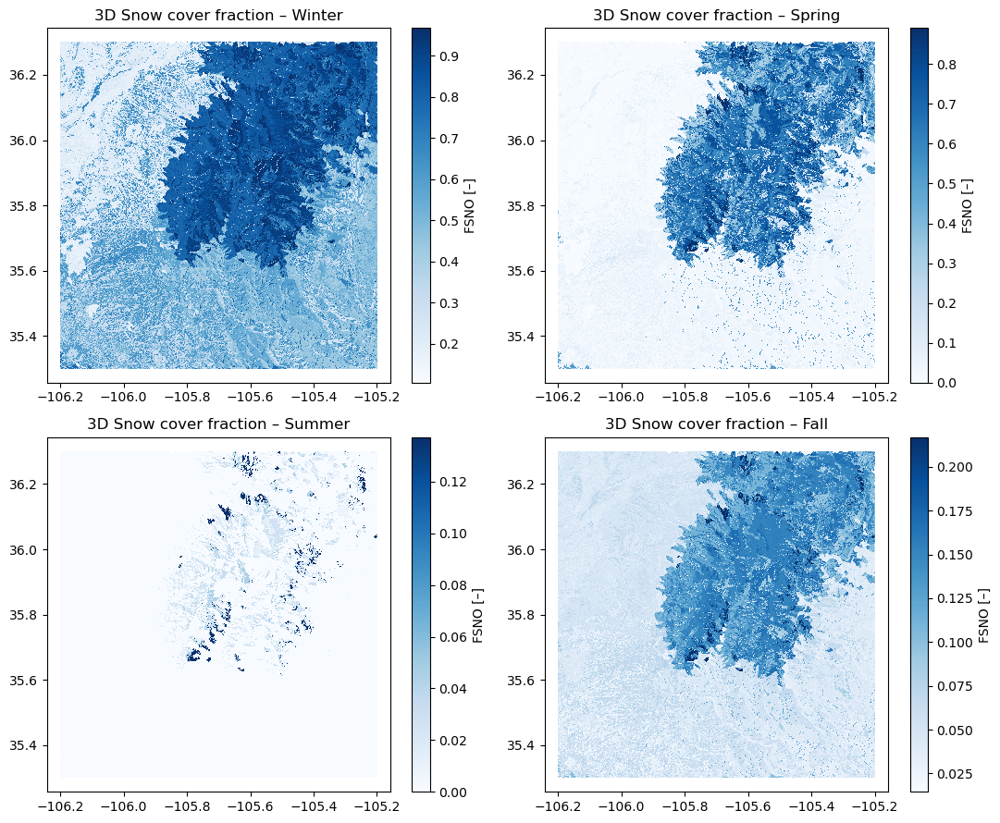

In [13]:
# snow cover fraction (fsno) seasonal plots

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        # -----------------------------
        # Fractional Snow Cover (rFSNO)
        # -----------------------------
        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)

        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[buffer:map_shape[0] - buffer + 1, buffer:map_shape[1] - buffer + 1]

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),cmap="Blues", shading="auto")

    ax.set_title(f"3D Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal1.png"),
    dpi=300
)
plt.show()


/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall


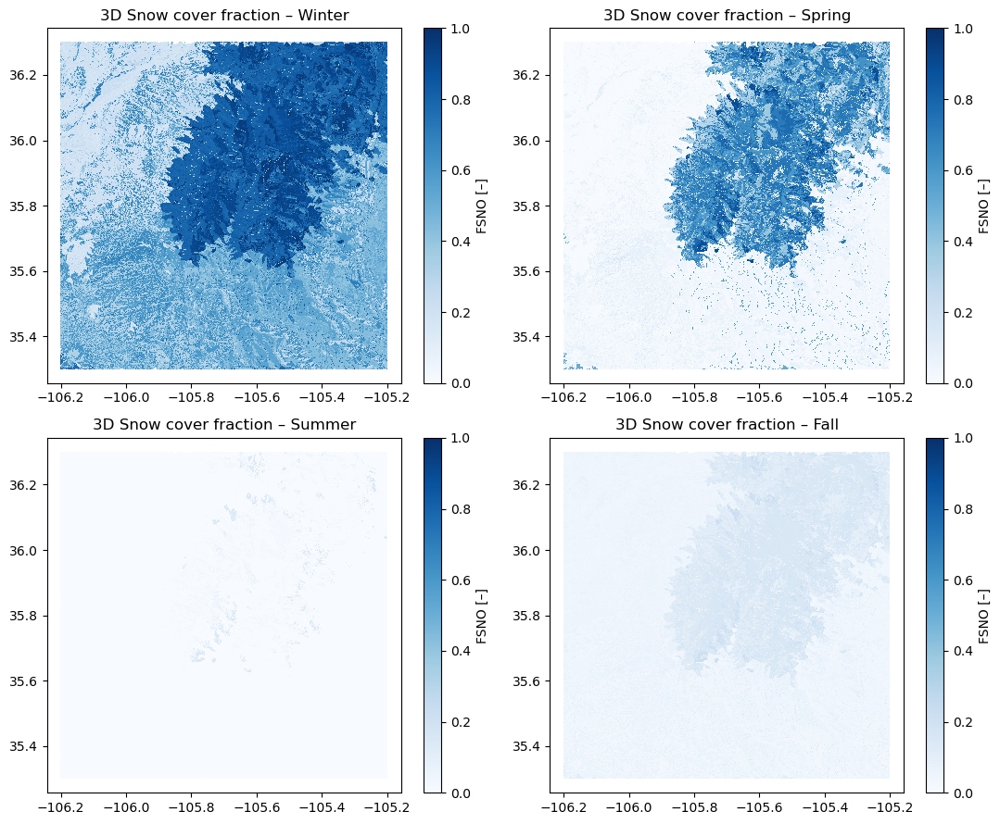

In [14]:
# snow cover fraction (fsno) seasonal plots

import matplotlib.colors as colors  # <-- add if not already imported

path = path_3d
print(path)

# HRU & CID rasters
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

tmp = np.copy(hrus)
tmp[:] = -9999.0

# 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# FIXED scale so that 0 is always the reference for no snow
fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    for c in range(1, 2):
        fp = nc.Dataset(path + f"/output_data/{c}/2016-01-01.nc")
        grp = fp.groups["data"]

        fsno = np.array(grp.variables["fsno"][:])   # (time, hru)
        fp.close()

        # Seasonal mask
        times_index = (
            (times.dt.month == my_months[0]) |
            (times.dt.month == my_months[1]) |
            (times.dt.month == my_months[2])
        )

        # Seasonal mean over time
        data_sel = fsno[times_index, :]             # (time, hru)
        data_ave = np.nanmean(data_sel, axis=0)     # (hru,)

        # Map HRU values to grid
        final_map = place_data(tmp, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_array(final_map, final_map == -9999)
    final_map[final_map == -9999] = np.nan

    map_shape = final_map.shape
    final_map = final_map[
        buffer:map_shape[0] - buffer + 1,
        buffer:map_shape[1] - buffer + 1
    ]

    im = ax.pcolormesh(
        coords_x, coords_y, np.flipud(final_map),
        cmap="Blues",
        norm=fsno_norm,          # <-- added: fixed 0–1 scale
        shading="auto"
    )

    ax.set_title(f"3D Snow cover fraction – {my_season}")
    fig.colorbar(im, ax=ax, label="FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_fsno_seasonal.png"),
    dpi=300
)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_fSCA_500m/modelgrid_4326
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


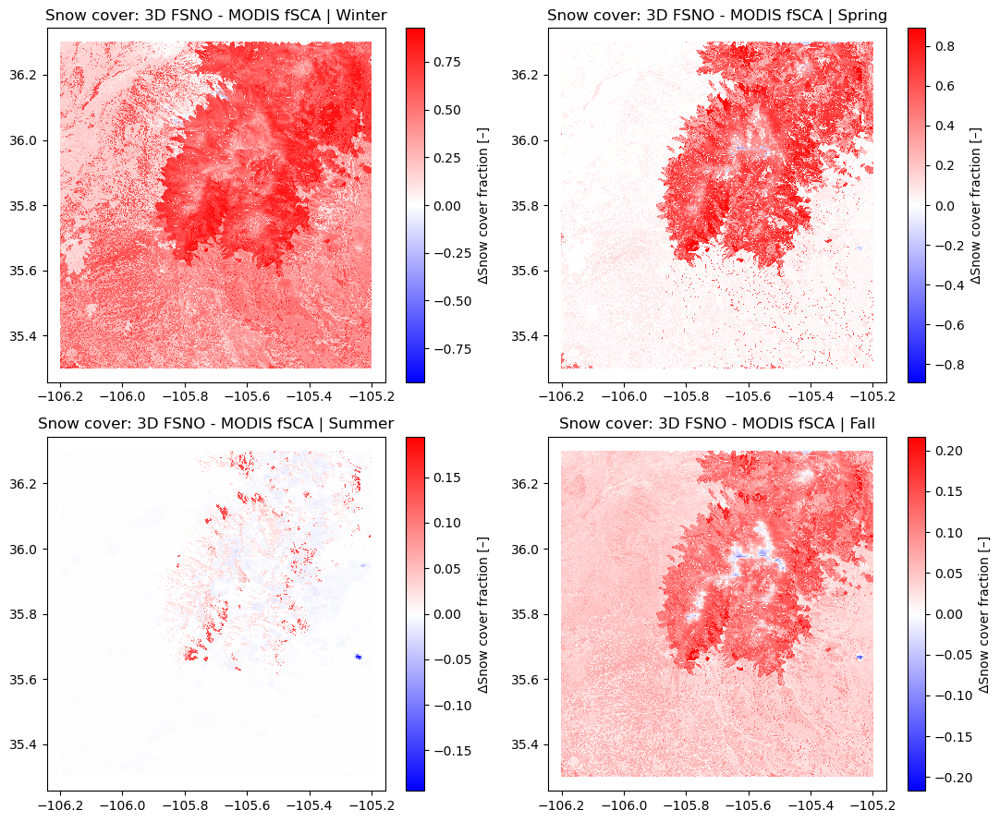

In [15]:
# 3D - MODIS seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  MODIS fSCA

print("3D:", path_3d)
modis_sat = "/scratch/alpine/battobrah@xsede.org/MODIS_fSCA_500m/modelgrid_4326"
print("MODIS:", modis_sat)

# use 3D domain for mapping
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly files (your filenames)
pat = re.compile(r".*MOD10A1_fSCA_monthlymean_(\d{4})_(\d{2})_MODELGRID_4326\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm   = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows = sorted(rows, key=lambda x: x[0])
    if len(rows) == 0:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # assumes MODIS is already on the HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # 3D model seasonal mean FSNO in HRU space
    fp_3d  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_3d_sel = fsno_3d[times_index, :]
    fsno_3d_ave = np.nanmean(fsno_3d_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.ma.masked_array(map_3d, map_3d == -9999)
    map_3d[map_3d == -9999] = np.nan

    # MODIS seasonal mean on model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modis_map = modis_map[buffer:modis_map.shape[0]-buffer+1, buffer:modis_map.shape[1]-buffer+1]

    # difference: 3D - MODIS
    final_map = map_3d - modis_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - MODIS fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3D_minus_MODIS_fSCA_maps.png"), dpi=300)
plt.show()


MODIS vs 3D: Winter
MODIS vs 3D: Spring
MODIS vs 3D: Summer
MODIS vs 3D: Fall


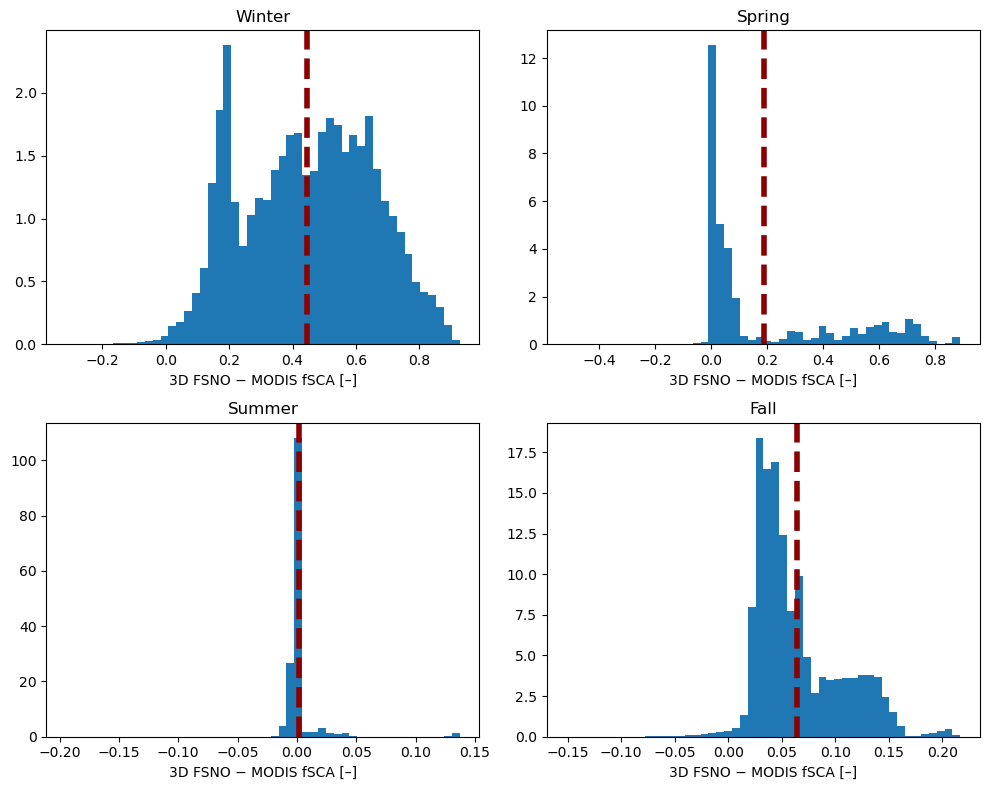

In [16]:
# 3D vs MODIS difference Histogram Plot (Snow cover fraction)

path_domain = path_3d

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modis_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No MODIS files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"MODIS vs 3D: {my_season}")

    # 3D seasonal mean FSNO (HRU space)
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)

    # MODIS seasonal mean (grid, already on model grid)
    modis_grid = modis_season_mean_grid(modis_rows, my_months)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map 3D HRU → grid
    fsno3d_grid = place_data(tmp, fsno3d_mean, hrus, cids, 1)
    fsno3d_grid = np.where(fsno3d_grid == -9999, np.nan, fsno3d_grid)
    fsno3d_grid = fsno3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno3d_grid - modis_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − MODIS fSCA [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_3D_minus_MODIS_fSCA.png"),
    dpi=300
)
plt.show()


PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
MODIS: /scratch/alpine/battobrah@xsede.org/MODIS_fSCA_500m/modelgrid_4326
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


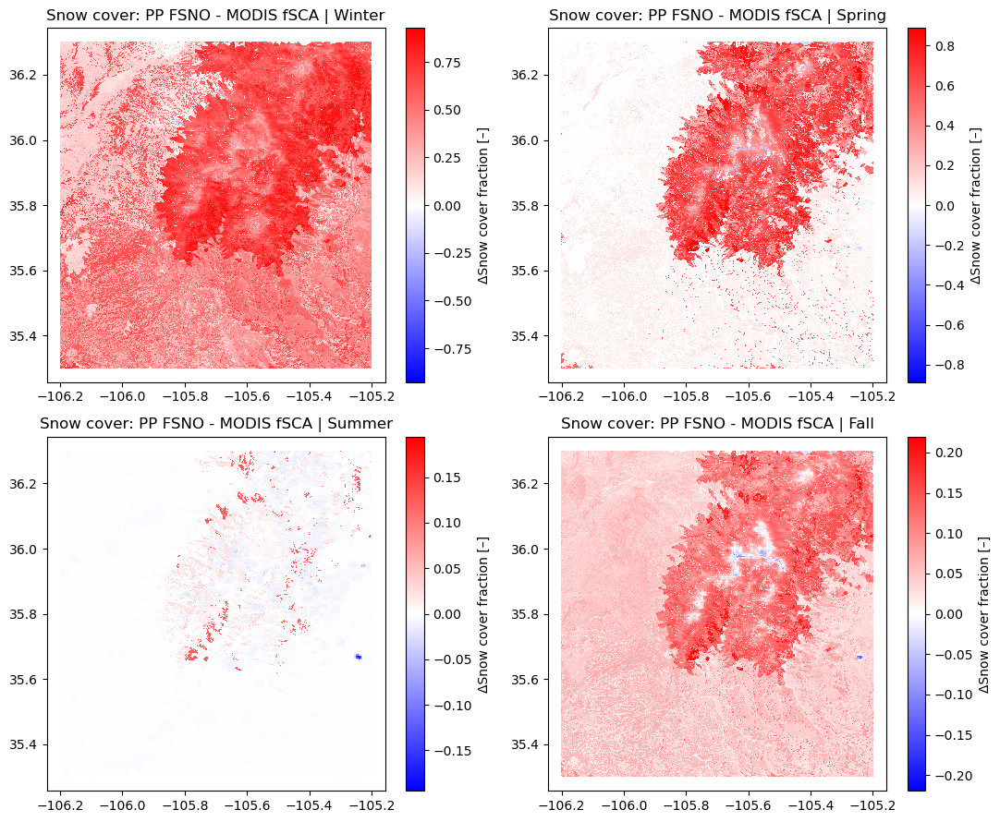

In [17]:
# PP - MODIS seasonal difference maps (Snow cover fraction)
# Difference = PP FSNO  -  MODIS fSCA

import os, glob, re
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("PP:", path_pp)
modis_sat = "/scratch/alpine/battobrah@xsede.org/MODIS_fSCA_500m/modelgrid_4326"
print("MODIS:", modis_sat)

# use PP domain for mapping
path = path_pp

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# MODIS monthly files (your filenames)
pat = re.compile(r".*MOD10A1_fSCA_monthlymean_(\d{4})_(\d{2})_MODELGRID_4326\.tif$")

def build_modis_rows(modis_folder):
    files = sorted(glob.glob(os.path.join(modis_folder, "*.tif")))
    rows = []
    for fp in files:
        m = pat.match(os.path.basename(fp))
        if not m:
            continue
        yyyy = int(m.group(1))
        mm   = int(m.group(2))
        dt = pd.Timestamp(yyyy, mm, 1)
        if dt.year < 2016 or dt.year > 2018:
            continue
        rows.append((dt, fp))
    rows = sorted(rows, key=lambda x: x[0])
    if len(rows) == 0:
        raise RuntimeError(f"No MODIS monthly files matched for 2016–2018 in: {modis_folder}")
    return rows

def modis_season_mean(rows, my_months):
    arrs = []
    for dt, fp in rows:
        if dt.month in my_months:
            arrs.append(read_grid(fp))  # MODIS already on HydroBlocks/model grid
    if len(arrs) == 0:
        return None
    return np.nanmean(np.stack(arrs, axis=0), axis=0)

modis_rows = build_modis_rows(modis_sat)

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # PP model seasonal mean FSNO in HRU space
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    fsno_pp_sel = fsno_pp[times_index, :]
    fsno_pp_ave = np.nanmean(fsno_pp_sel, axis=0)  # (hru,)

    # map model HRU -> grid
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.ma.masked_array(map_pp, map_pp == -9999)
    map_pp[map_pp == -9999] = np.nan

    # MODIS seasonal mean on model grid
    modis_map = modis_season_mean(modis_rows, my_months)
    if modis_map is None:
        ax.axis("off")
        continue

    # remove buffer
    map_shape = map_pp.shape
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    modis_map = modis_map[buffer:modis_map.shape[0]-buffer+1, buffer:modis_map.shape[1]-buffer+1]

    # difference: PP - MODIS
    final_map = map_pp - modis_map

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: PP FSNO - MODIS fSCA | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_PP_minus_MODIS_fSCA_maps.png"), dpi=300)
plt.show()


MODIS vs PP: Winter
MODIS vs PP: Spring
MODIS vs PP: Summer
MODIS vs PP: Fall


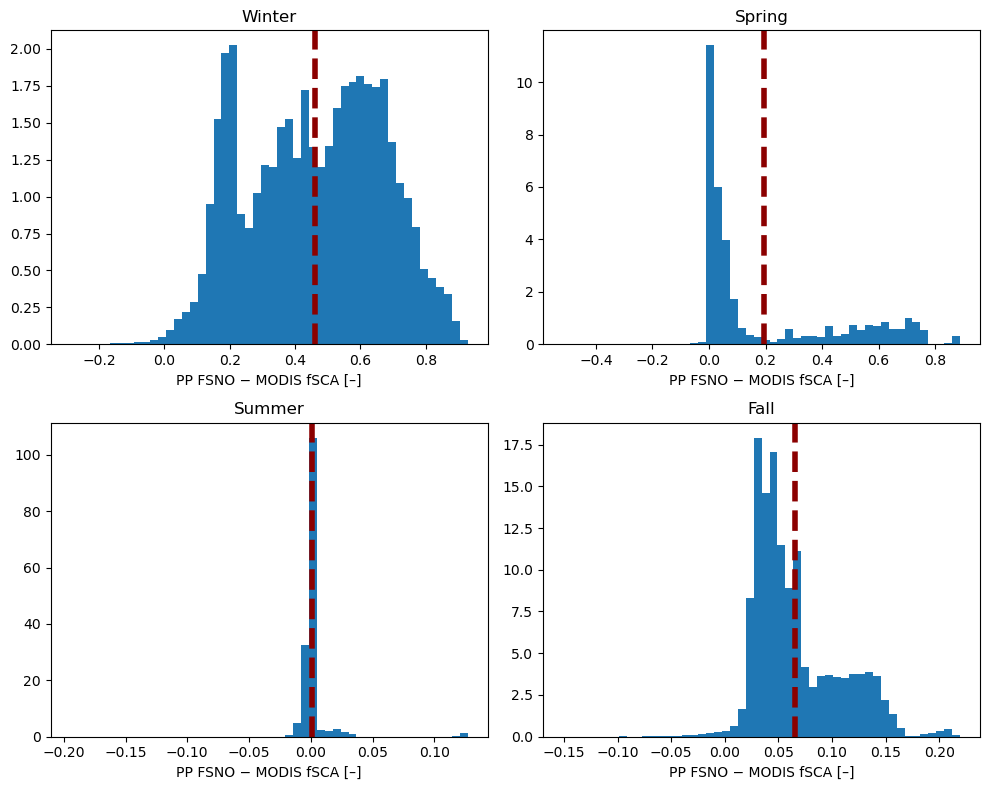

In [18]:
# PP vs MODIS difference Histogram Plot (Snow cover fraction)

path_domain = path_pp  # <-- changed (was path_3d)

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

def modis_season_mean_grid(rows, months):
    season_arrays = [read_grid(fp) for (dt, fp) in rows if dt.month in months]
    if not season_arrays:
        raise RuntimeError(f"No MODIS files found for months={months}")
    return np.nanmean(np.stack(season_arrays, axis=0), axis=0)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"MODIS vs PP: {my_season}")  # <-- changed label

    # PP seasonal mean FSNO (HRU space)
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")  # <-- changed (was path_3d)
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()

    idx = times.dt.month.isin(my_months).to_numpy()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)  # <-- changed name

    # MODIS seasonal mean (grid, already on model grid)
    modis_grid = modis_season_mean_grid(modis_rows, my_months)
    modis_grid = modis_grid[buffer:-buffer+1, buffer:-buffer+1]

    # map PP HRU → grid
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)  # <-- changed
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # difference
    diff = fsno_pp_grid - modis_grid  # <-- PP - MODIS
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    # HIST
    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed',
               linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("PP FSNO − MODIS fSCA [–]")  # <-- changed

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir,
                 "res_hist_snow_PP_minus_MODIS_fSCA.png"),  # <-- changed filename
    dpi=300
)
plt.show()


3D: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d/
PP: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp/
Creating differences plot for Winter
Creating differences plot for Spring
Creating differences plot for Summer
Creating differences plot for Fall


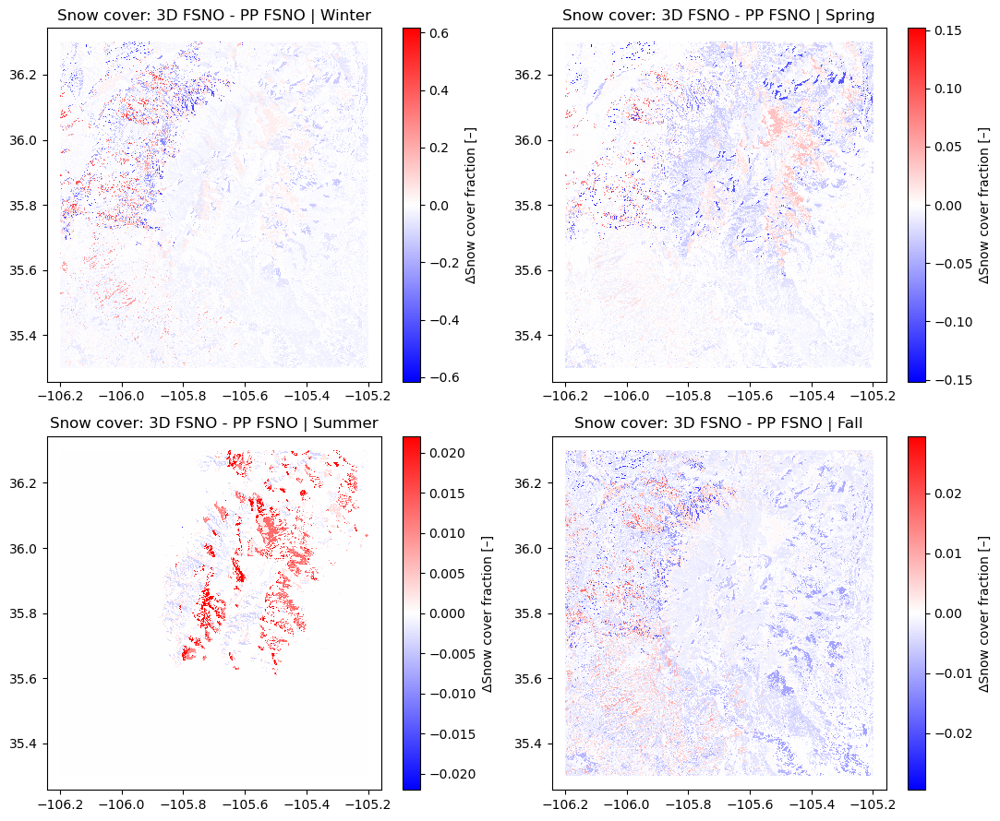

In [19]:
# 3D - PP seasonal difference maps (Snow cover fraction)
# Difference = 3D FSNO  -  PP FSNO

import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("3D:", path_3d)
print("PP:", path_pp)

# use 3D domain for mapping (hrus/cids should match; we map both to the same grid)
path = path_3d

# read mapping rasters
hrus  = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids  = gdal_tools.read_raster(path + "postprocess/cids.vrt")
tmp   = np.copy(hrus)
tmp[:] = -9999.0

# seasons
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

# PLOT: 2x2
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]
    print("Creating differences plot for {}".format(my_season))

    # seasonal mask (same for both)
    times_index = ((times.dt.month == my_months[0]) |
                   (times.dt.month == my_months[1]) |
                   (times.dt.month == my_months[2]))

    # ----------------------------
    # 3D seasonal mean FSNO (HRU)
    # ----------------------------
    fp_3d  = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    grp_3d = fp_3d.groups["data"]
    fsno_3d = np.array(grp_3d.variables["fsno"][:])   # (time, hru)
    fp_3d.close()

    fsno_3d_ave = np.nanmean(fsno_3d[times_index, :], axis=0)  # (hru,)
    map_3d = place_data(tmp, fsno_3d_ave, hrus, cids, 1)
    map_3d = np.where(map_3d == -9999, np.nan, map_3d)

    # ----------------------------
    # PP seasonal mean FSNO (HRU)
    # ----------------------------
    fp_pp  = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    grp_pp = fp_pp.groups["data"]
    fsno_pp = np.array(grp_pp.variables["fsno"][:])   # (time, hru)
    fp_pp.close()

    fsno_pp_ave = np.nanmean(fsno_pp[times_index, :], axis=0)  # (hru,)
    map_pp = place_data(tmp, fsno_pp_ave, hrus, cids, 1)
    map_pp = np.where(map_pp == -9999, np.nan, map_pp)

    # ----------------------------
    # remove buffer (both)
    # ----------------------------
    map_shape = map_3d.shape
    map_3d = map_3d[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]
    map_pp = map_pp[buffer:map_shape[0]-buffer+1, buffer:map_shape[1]-buffer+1]

    # difference: 3D - PP
    final_map = map_3d - map_pp

    # symmetric diverging norm centered at 0
    vmax = np.nanmax(np.abs(final_map))
    if not np.isfinite(vmax) or vmax == 0:
        ax.axis("off")
        continue
    diff_norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(coords_x, coords_y, np.flipud(final_map),
                       cmap="bwr", norm=diff_norm, shading="auto")

    ax.set_title("Snow cover: 3D FSNO - PP FSNO | {}".format(my_season))
    fig.colorbar(im, ax=ax, label="ΔSnow cover fraction [–]")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, "res_snow_3D_minus_PP_FSNO_maps.png"), dpi=300)
plt.show()


3D vs PP: Winter
3D vs PP: Spring
3D vs PP: Summer
3D vs PP: Fall


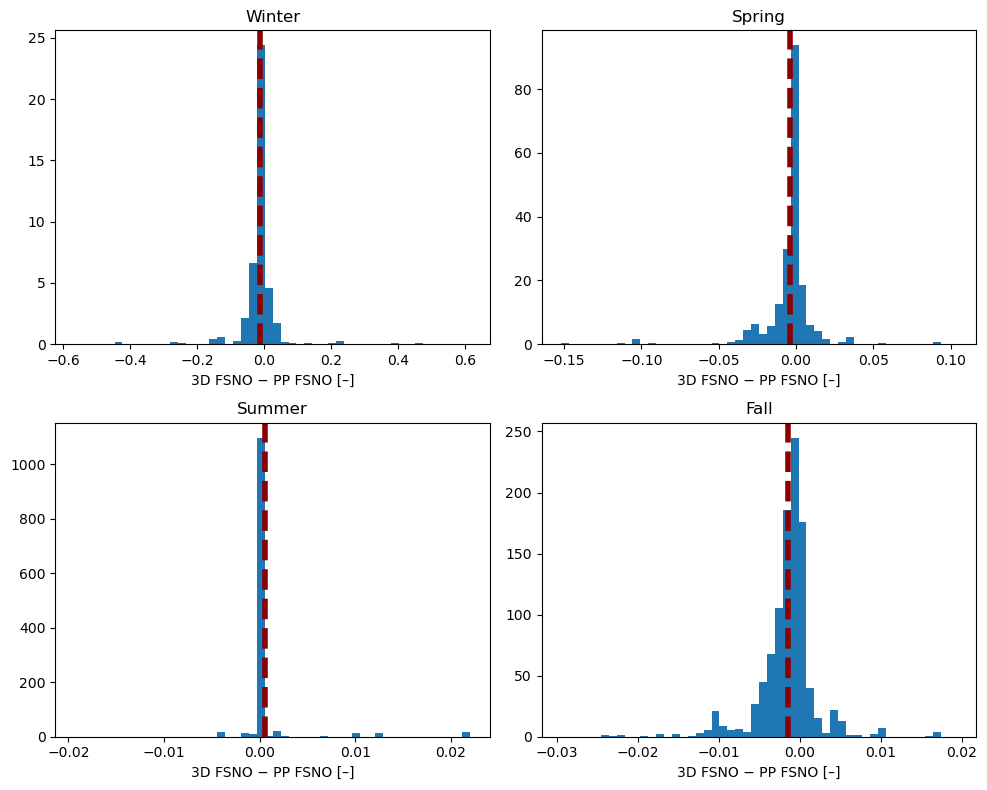

In [20]:
# 3D vs PP difference Histogram Plot (Snow cover fraction)
# Difference = 3D FSNO - PP FSNO

path_domain = path_3d  # use 3D domain for mapping

hrus = gdal_tools.read_raster(path_domain + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path_domain + "postprocess/cids.vrt")

tmp = np.copy(hrus)
tmp[:] = -9999.0

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
season_months = [(12,1,2), (3,4,5), (6,7,8), (9,10,11)]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"3D vs PP: {my_season}")

    # seasonal mask
    idx = times.dt.month.isin(my_months).to_numpy()

    # -------------------------
    # 3D seasonal mean FSNO (HRU)
    # -------------------------
    fp_3d = nc.Dataset(path_3d + "/output_data/1/2016-01-01.nc")
    fsno_3d = np.array(fp_3d.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_3d.close()
    fsno_3d_mean = np.nanmean(fsno_3d[idx, :], axis=0)

    # map 3D HRU → grid
    fsno_3d_grid = place_data(tmp, fsno_3d_mean, hrus, cids, 1)
    fsno_3d_grid = np.where(fsno_3d_grid == -9999, np.nan, fsno_3d_grid)
    fsno_3d_grid = fsno_3d_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # PP seasonal mean FSNO (HRU)
    # -------------------------
    fp_pp = nc.Dataset(path_pp + "/output_data/1/2016-01-01.nc")
    fsno_pp = np.array(fp_pp.groups["data"].variables["fsno"][:])  # (time, hru)
    fp_pp.close()
    fsno_pp_mean = np.nanmean(fsno_pp[idx, :], axis=0)

    # map PP HRU → grid (onto SAME grid)
    fsno_pp_grid = place_data(tmp, fsno_pp_mean, hrus, cids, 1)
    fsno_pp_grid = np.where(fsno_pp_grid == -9999, np.nan, fsno_pp_grid)
    fsno_pp_grid = fsno_pp_grid[buffer:-buffer+1, buffer:-buffer+1]

    # -------------------------
    # difference + histogram
    # -------------------------
    diff = fsno_3d_grid - fsno_pp_grid
    arr = diff.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=50, density=True)
    ax.axvline(np.mean(arr), linestyle='dashed', linewidth=4, color='darkred')

    ax.set_title(my_season)
    ax.set_xlabel("3D FSNO − PP FSNO [–]")

plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "res_hist_snow_3D_minus_PP_FSNO.png"),
    dpi=300
)
plt.show()
